# Processing of RO-Crate for publishing
This notebook will read and RO-Crate file from galaxy, extract the provenance information as PROV-O in JSON-LD and save it into a new version of the RO-Crate.

1. read galaxy ro-crate
2. read the workflow file to get the prospective provenance
3. read the workflow run to get the retrospective provenance
4. merge the provenances into a PROV-O graph
5. save the PROV-O graph in the RO-Crate
6. get a publishable package consisting of RO-Crate + context (a JSON-LD file). The context metadata as JSON-LD is intended to facilitate discovery and interoperability
7. publish package to Invenio RDM (Zenodo if possible)


In [1]:
import zipfile
from pathlib import Path
from rdflib import Graph, Namespace, URIRef, Literal
from rdflib.namespace import RDF, RDFS, XSD, DCTERMS
import json

# library to support visualisation of graphs
from rdflib.extras.external_graph_libs import rdflib_to_networkx_graph

# pyvis used to display the graphs
from pyvis.network import Network


# Namespaces
PROV = Namespace("http://www.w3.org/ns/prov#")
SCHEMA = Namespace("http://schema.org/")
SKOS = Namespace("http://www.w3.org/2004/02/skos/core#")
PPLAN = Namespace("https://vocab.linkeddata.es/p-plan#")

file_formats = {"txt":"text/plain", "cif": "chemical/x-cif",
                "png":"image/png", "prj": "application/vnd.demeter.athena",
                "sp":"text/csv", "gds":"text/csv", "feffit":"text/plain", 
                "feff":"text/csv", "zip":"application/zip",
                "inp":"chemical/x-feff-input"}

# read file from zipped RO-Crate file
def get_file_from_rocratezip(zip_file, file_name):
    roc_zip_file = zipfile.ZipFile(zip_file)
    return roc_zip_file.open(file_name)
    
# Read the zipped crate and get main metadata file
def load_rocrate_metadata(crate_file):
    roc_zip_file = zipfile.ZipFile(crate_file)
    f = get_file_from_rocratezip(crate_file, "ro-crate-metadata.json")
    crate = json.load(f)
    return crate["@graph"]

#Return all JSON-LD entities of a given @type.
def find_entities(graph, type_name):
    return [e for e in graph if type_name in e.get("@type", [])]

#Convert RO-Crate IDs to URIs.
def to_uri(crate_base, entity_id):
    return URIRef(crate_base + entity_id)

#Convert json-ld crate to turtle
def crate_to_turtle(crate_path):
    g = Graph()
    roc_zip_file = zipfile.ZipFile(crate_path)
    f = roc_zip_file.open("ro-crate-metadata.json")
    g.parse(f,format="json-ld")
    out_ttl="ro-crate-metadata.ttl"
    g.serialize(destination=out_ttl, format="turtle")

# get galaxy workflow file from RO-Crate
def get_workflow_json(ro_crate_zip):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_files = find_entities(graph, "File")
    workflow_file = ""
    for a in roc_files:
        if a['@id'][-3:] == ".ga" :
            workflow_file = a['@id']
            break    
    f = get_file_from_rocratezip(ro_crate_zip, workflow_file)
    wf_ga_json = json.load(f)
    return wf_ga_json

# get txt containing entities RO-Crate metadata:
# invocation, datasets, etc
def get_roc_json_part(ro_crate_zip, file_name):
    graph = load_rocrate_metadata(ro_crate_zip)
    roc_file = ""
    roc_all_files = find_entities(graph, "File")
    for a in roc_all_files:
        if file_name in a['@id']:
            roc_file = a['@id']
            break
    f = get_file_from_rocratezip(ro_crate_zip, roc_file) 
    file_json = json.load(f)
    return file_json

# data sets are mapped to history objects
def get_mapped_ds(datasets_json, history_mapping):
    ds_id = ""
    for a_ds in datasets_json:
        if 'copied_from_history_dataset_association_id_chain' in a_ds:
            for an_id in a_ds['copied_from_history_dataset_association_id_chain']:
                if an_id == history_mapping:
                    # "History item: {an_id}, Mapped to dataset: {a_ds['encoded_id']}"
                    ds_id = a_ds['encoded_id']
                    break
    return ds_id

# link ds generator to corresponding wf step
def get_wf_step(ds_uri, a_graph):
    ret_val = None
    for s, p, o in a_graph.triples((None, PROV.used, ds_uri)):
        for s1, p1, o1 in a_graph.triples((s, PPLAN.correspondsToStep, None)):
            for s2, p2, o2 in a_graph.triples((o1, PPLAN.isPrecededBy, None)):
                ret_val = o2
                break
    return ret_val

# correct association of sw agents to actions instead of steps
def redirect_software_agents(a_graph):
    to_remove = set()
    to_add = set()
    
    for an_agent in a_graph.subjects(RDF.type, PROV.SoftwareAgent):
        for step in a_graph.subjects(PROV.wasAssociatedWith, an_agent):
            if (step, RDF.type, PPLAN.Step) not in a_graph:
                continue
    
            for prov_activity in a_graph.subjects(PPLAN.correspondsToStep, step):
                to_remove.add((step, PROV.wasAssociatedWith, an_agent))
                to_add.add((prov_activity, PROV.wasAssociatedWith, an_agent))
    
                for used in a_graph.objects(prov_activity, PROV.used):
                    to_add.add((used, PROV.wasAttributedTo, an_agent))
    
                for gen in a_graph.subjects(PROV.wasGeneratedBy, prov_activity):
                    to_add.add((gen, PROV.wasAttributedTo, an_agent))
        
    for triple in to_remove:
        a_graph.remove(triple)
    
    for triple in to_add:
        a_graph.add(triple)

# add custom labels to activities
def custom_labels(a_graph):
    for an_activity in a_graph.subjects(RDF.type, PROV.Activity):
        #print(f"Activity {an_activity}")
        for an_agent in a_graph.objects(an_activity, PROV.wasAssociatedWith):
            #print(f"Activity {an_activity} associated with {an_agent}")
            for agent_label in a_graph.objects(an_agent, RDFS.label):
                #print(f"Agent label: {agent_label}")
                d_label = str(agent_label)
                pref_label = ""
                if d_label == "larch_athena":
                    pref_label = "process and normalise XAS"
                elif d_label == "larch_artemis":
                    pref_label = "FEFF fit of XAS"
                elif d_label == "larch_select_paths":
                    pref_label = "select FEFF paths"
                elif d_label == "larch_feff":
                    pref_label = "calculate FEFF paths from crystal"
                elif d_label == "larch_lcf":
                    pref_label = "linear combination fit of XAS"
                elif d_label == "larch_plot":
                    pref_label = "plot XAS data"
                elif d_label == "larch_criteria_report":
                    pref_label = "report on FEFF fitting"
                elif d_label == "DATA_FETCH":
                    pref_label = "fetch data from history"
            if pref_label != "":
                a_graph.add((an_activity, SKOS.prefLabel, Literal(pref_label)))

    
# extract steps from wf and invocation files to create prov plan
def extract_prov_json(crate_path,output_file="galaxy_run_prov.ttl"):
    workflow_file = ""
    invocation_file = "" 

    # Load workflow (prospective provenance)
    wf = get_workflow_json(crate_path)
    steps = wf.get("steps", {})

    # Load invocation (retrospective provenance)
    inv = get_roc_json_part(crate_path,"invocation_attrs.txt")
    inv_steps = inv[0].get("steps", {})

    # Load dataset attributes (encoding, names, ) 
    # to gather dataset attributes
    ds_attributes = get_roc_json_part(crate_path,"datasets_attrs.txt")

    # Load job attributes
    # gather input links
    invoked_jobs = get_roc_json_part(crate_path,"jobs_attrs.txt")
    
    g = Graph()
    g.bind("prov", PROV)
    g.bind("schema", SCHEMA)
    g.bind("skos",SKOS)
    g.bind("p-plan", PPLAN)

    base = "/"

    # --- 1. Workflow definition as prov:Plan ---
    wf_uri = URIRef(base + "workflow")
    g.add((wf_uri, RDF.type, PPLAN.Plan))
    g.add((wf_uri, RDFS.label, Literal(wf.get("name", "Galaxy Workflow"))))

    # --- 2. Prospective provenance: workflow steps ---
    for step_id, step in steps.items():
        step_uri = URIRef(base + f"step/{step_id}")
        g.add((step_uri, RDF.type, PPLAN.Step))
        step_label = step.get("label") or step.get("tool_id")
        g.add((step_uri, RDFS.label, Literal(step_label)))

        # Link step to workflow plan
        g.add(( step_uri, PPLAN.isStepOfPlan, wf_uri))

        # Prospective inputs
        for inp in step.get("input_connections", {}).values():
            if isinstance(inp, dict) and "id" in inp:
                src = URIRef(base + f"step/{inp['id']}")
                g.add((step_uri, PPLAN.isPrecededBy, src))

        # Tool as SoftwareAgent (prospective) 
        tool_id = step.get("tool_id")
        if tool_id:
            tool_uri = URIRef(base+f"{tool_id}")
            tool_label = tool_id.split("/")[-2]
            tool_version = tool_id.split("/")[-1]
            g.add((tool_uri, RDF.type, PROV.SoftwareAgent))
            g.add((tool_uri, RDFS.label, Literal(tool_label)))
            g.add((step_uri, PROV.wasAssociatedWith, tool_uri)) # need to associate to activity not step
            #g.add((tool_uri, SKOS.prefLabel, Literal(tool_label)))
            g.add((tool_uri, SCHEMA.softwareVersion, Literal(tool_version)))
            
    # --- 3. Retrospective provenance: actual execution ---
    for inv_step in inv_steps:
        job = inv_step.get("job")
        
        if not job:
            continue
        step_index = f"{inv_step['order_index']}"
        job_id = job['encoded_id']
        
        act_uri = URIRef(base + f"run/{job_id}")
        g.add((act_uri, RDF.type, PROV.Activity))
        g.add((act_uri, RDFS.label, Literal(f"Execution of step {step_index}")))
    
        # Link execution to prospective step
        step_uri = URIRef(base + f"step/{step_index}")
        g.add((act_uri, PPLAN.correspondsToStep, step_uri))
    
        # Inputs
        for inp_name, dataset in inv_step.get("inputs", {}).items():
            ent_uri = URIRef(base + f"dataset/{dataset['id']}")
            g.add((ent_uri, RDF.type, PROV.Entity))
            g.add((act_uri, PROV.used, ent_uri))      
        
        # Outputs
        step_outputs = inv_step.get("outputs")
        for an_output in step_outputs:
            out_name = an_output['output_name']
            dataset = an_output['dataset']
            ent_uri = URIRef(base + f"dataset/{dataset['encoded_id']}")
            g.add((ent_uri, RDF.type, PROV.Entity))
            g.add((ent_uri, PROV.wasGeneratedBy, act_uri))
            g.add((ent_uri, RDFS.label, Literal(out_name)))

    # Add datset attributes
    for a_ds in ds_attributes:
        ent_uri = (URIRef(base + f"dataset/{a_ds['encoded_id']}"))
        format_str =  file_formats[a_ds['extension']]

        g.add((ent_uri, RDF.type, PROV.Entity)) # duplicated only used for WF_inputs which are not in invocation
        g.add((ent_uri, DCTERMS.format, Literal(format_str)))
        g.add((ent_uri, DCTERMS.description, Literal(a_ds['info'])))
        g.add((ent_uri, SCHEMA.name, Literal(a_ds['file_name'])))
        g.add((ent_uri, SKOS.prefLabel, Literal(a_ds['name']) ))

    # Add the missing links to inputs
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        # link all used datasets to activites
        for a_mapping in a_job['input_dataset_mapping']:
            for a_ds_id in  a_job['input_dataset_mapping'][a_mapping]:
                ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                g.add((job_uri, PROV.used, ds_uri))
                
    for a_job in invoked_jobs:
        job_uri = URIRef(base + f"run/{a_job['encoded_id']}")
        if not (job_uri, RDF.type, PROV.Activity) in g:
            tool_label = a_job['tool_id'].lstrip("_").rstrip("_")
            tool_version = a_job['tool_version']
            tool_uri = URIRef(str(a_job['command_line'].split(' ')[1].strip("'")))
            g.add((job_uri, RDF.type, PROV.Activity))
            g.add((job_uri, RDFS.label, Literal(tool_label)))
            g.add((tool_uri, RDF.type, PROV.SoftwareAgent))
            g.add((tool_uri, RDFS.label, Literal(tool_label)))
            g.add((job_uri, PROV.wasAssociatedWith, tool_uri))
            g.add((tool_uri, SCHEMA.softwareVersion, Literal(tool_version)))
            
            for a_mapping in a_job['output_dataset_mapping']:
                for a_mapping_id in  a_job['output_dataset_mapping'][a_mapping]:
                    a_ds_id = get_mapped_ds(ds_attributes, a_mapping_id)
                    ds_uri = URIRef(base + f"dataset/{a_ds_id}")
                    g.add((ds_uri, PROV.wasGeneratedBy, job_uri))
                    g.add((ds_uri, PROV.wasAttributedTo, tool_uri))
                    # link to associated plan activity
                    step_uri = get_wf_step(ds_uri, g)
                    if step_uri != None:
                        g.add((job_uri, PPLAN.correspondsToStep, step_uri))

    # relocate associations to SoftwareAgents 
    redirect_software_agents(g)
    # Assing human readable labels to activities
    custom_labels(g)
    
    # --- Save ---
    g.serialize(destination=output_file, format="turtle")

    context = {
        "@vocab": "http://www.w3.org/ns/prov#",
        "prov": "http://www.w3.org/ns/prov#",
        "p-plan": "https://vocab.linkeddata.es/p-plan#",
        "schema": "http://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "xsd": "http://www.w3.org/2001/XMLSchema#",
        "dcterms": "http://purl.org/dc/terms/"
    }

    g.serialize(destination=output_file+".json", format="json-ld", 
                context=context, auto_compact=True, indent=2)

    return g
        

input_folder = "./input"
file_name = "FeS2-Analysis.rocrate.zip"

file_path = Path(input_folder,file_name)

if file_path.exists():
    print(f"Working with {str(file_path)}")
    roc_zip_file = zipfile.ZipFile(file_path)

    ro_crate_contents = roc_zip_file.namelist()

    f = roc_zip_file.open("ro-crate-metadata.json")
    content = f.read()

crate_to_turtle(file_path)

roc_graph = extract_prov_json(file_path)

Working with input\FeS2-Analysis.rocrate.zip


In [2]:
nx_graph = rdflib_to_networkx_graph(roc_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 105 nodes and 181 edges loaded successfully
nx.html


# Display PROV-O graph 
We wan to display the graph using the notation from the W3C document ([PROV-O](https://www.w3.org/TR/prov-o/)). 

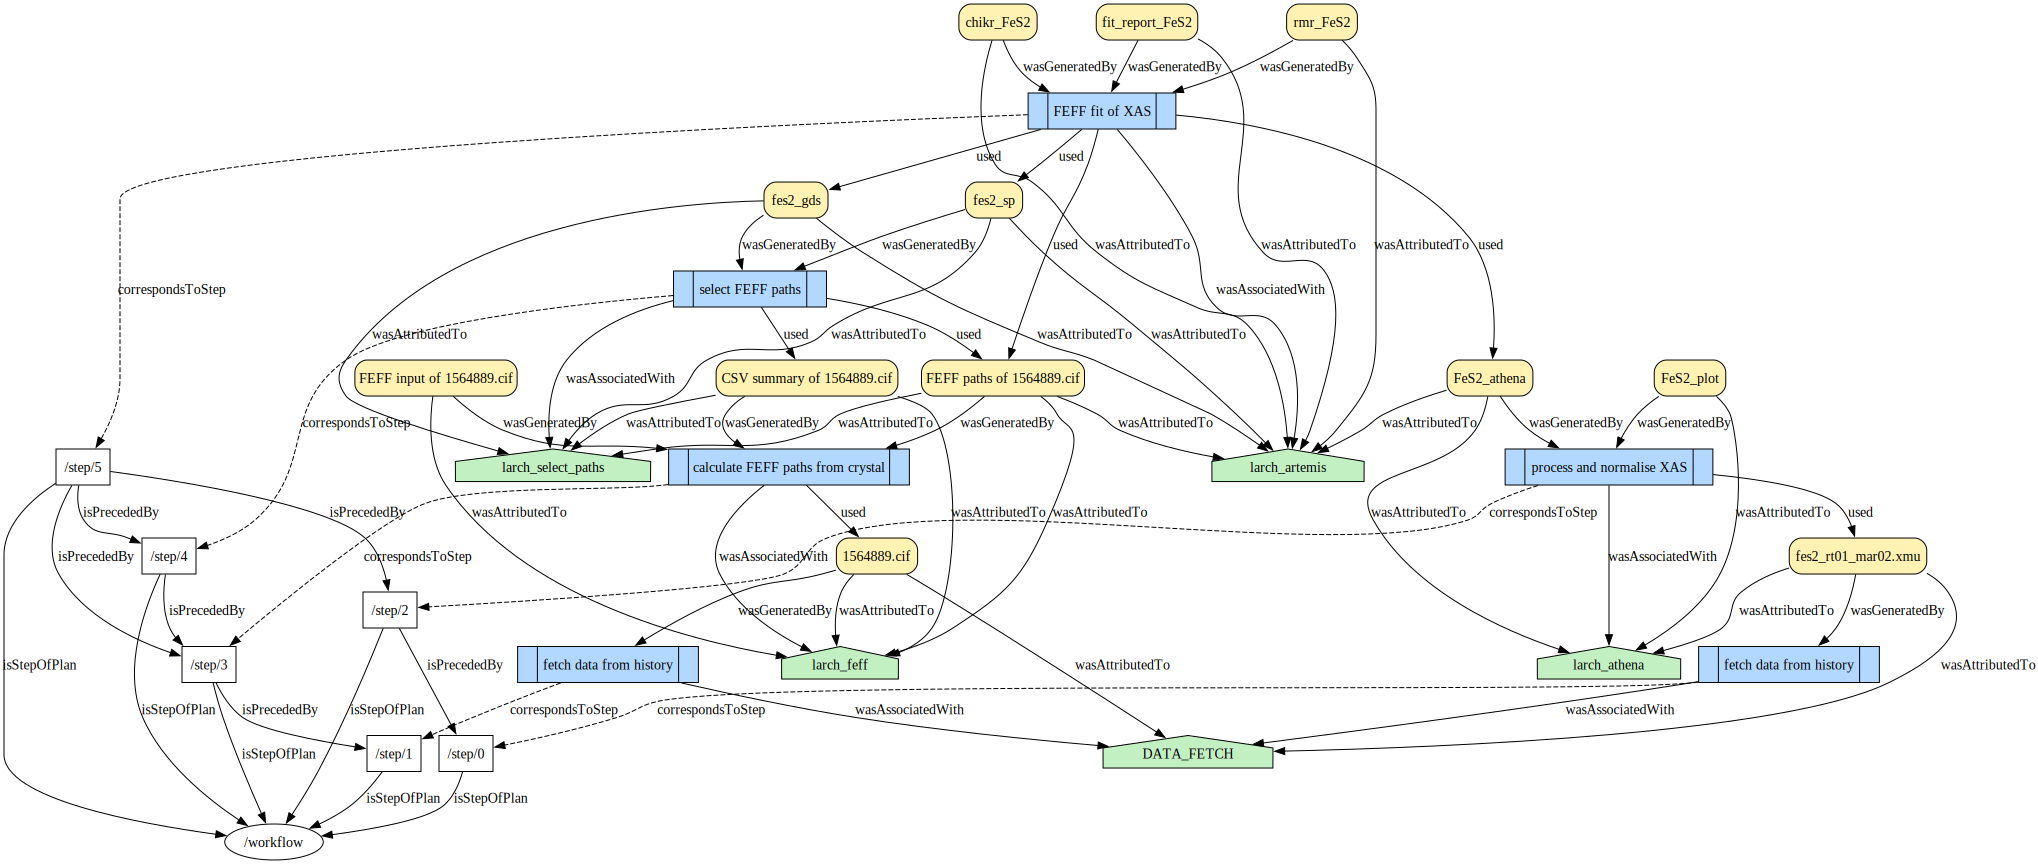

In [3]:
from rdflib import Graph, Namespace, RDF
from graphviz import Digraph
from IPython.display import display
import copy

import os

def get_a_label(graph_thing, a_subject):
    # Try SKOS prefLabel
    for a_label in graph_thing.objects(a_subject, SKOS.prefLabel):
        return str(a_label)

    # Try RDFS label
    for a_label in graph_thing.objects(a_subject, RDFS.label):
        return str(a_label)
        
    return ""

def draw_pplan_only(prov_graph):
    dot = Digraph("prov")

    search_graph = copy.deepcopy(prov_graph)

    for s, p, o in prov_graph:
        node_str = get_a_label(search_graph, s)
        if (s, RDF.type, PPLAN.Step) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label=node_str, shape="box")
        elif (s, RDF.type, PROV.Activity) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        if p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_only(prov_graph):
    dot = Digraph("prov")

    search_graph = copy.deepcopy(prov_graph)

    for s, p, o in prov_graph:
        # classify nodes
        node_str = get_a_label(search_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in prov_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0> |<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in prov_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

def draw_prov_full(prov_graph):
    dot = Digraph("prov")

    search_graph = copy.deepcopy(prov_graph)

    for s, p, o in prov_graph:
         # classify nodes
        node_str = get_a_label(search_graph, s)
        if node_str == "":
            node_str = str(s) 
        if (s, RDF.type, PROV.Entity) in prov_graph:
            dot.node(s, label=node_str, shape="box", style="rounded, filled", fillcolor="#fff2b2")
        elif (s, RDF.type, PROV.Activity) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label = f"<f0>|<f1>{node_str}|<f2> ", shape="record", style="filled", fillcolor="#b2d8ff")
        elif (s, RDF.type, PROV.SoftwareAgent) in prov_graph:
            dot.node(s, label=node_str, shape="house", style="filled", fillcolor="#c2f0c2")
        elif (s, RDF.type, PPLAN.Step) in prov_graph:
            if not ("/run/") in str(s):
                node_str = str(s) # don convert steps, their label is the tool ID
            dot.node(s, label=node_str, shape="box")
            
    
        # add edges with labels
        if p.startswith(PROV):
            dot.edge(str(s), str(o), label=p.split("#")[-1])
        elif p.startswith(PPLAN):
            if "correspondsTo" in str(p):
                dot.edge(str(s), str(o), label=p.split("#")[-1], style="dashed")
            else:
                dot.edge(str(s), str(o), label=p.split("#")[-1])
    return dot

# this path is needed for grapviz to work on win
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin/'

dot_prov_full = draw_prov_full(roc_graph)
dot_prov_full.render("prov_full", format="png")
display(dot_prov_full)

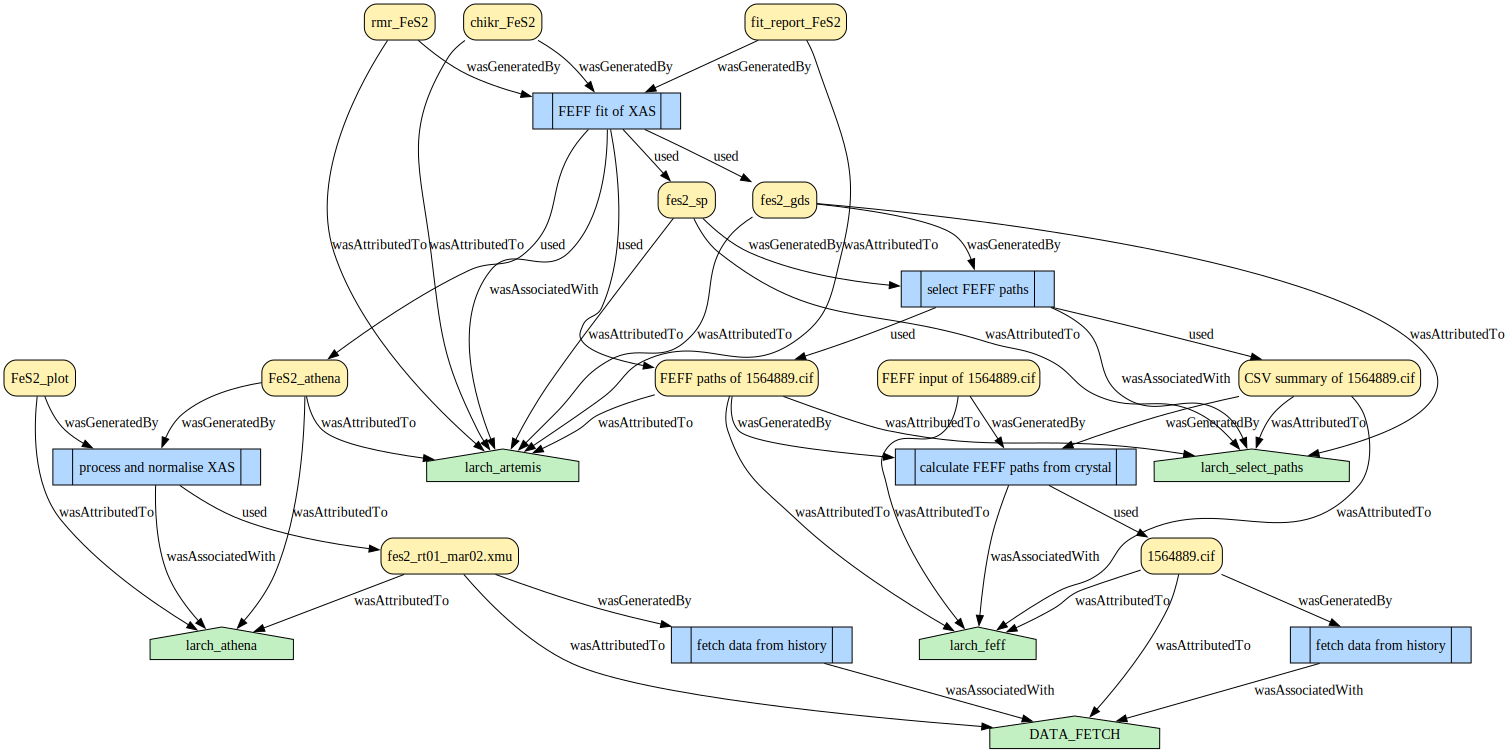

In [4]:
prov_dot = draw_prov_only(roc_graph)
prov_dot.render("prov_only_graph", format="png")
display(prov_dot)

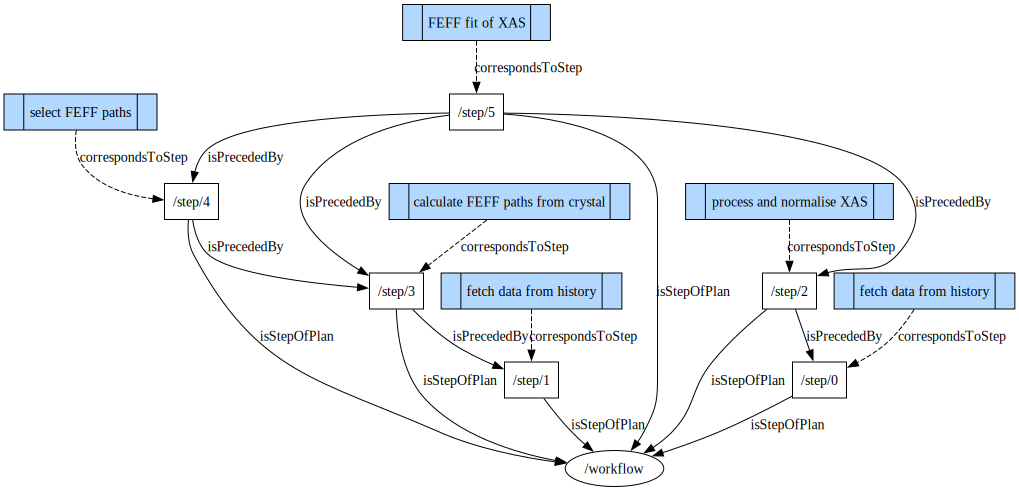

In [5]:
plan_dot = draw_pplan_only(roc_graph)
plan_dot.render("plan_only_graph", format="png")
display(plan_dot)

# Present provenance in table
We need to build a table from the RDF graph. The table shows the activity, the agent, the resulting dataset and the inputs that helped creating it.

activity -> agent/tool -> Entity (dataset) -> inputs 


In [6]:
# Present provenance as a table 
import pandas as pd

qres = roc_graph.query("""
PREFIX prov:   <http://www.w3.org/ns/prov#>
PREFIX skos:   <http://www.w3.org/2004/02/skos/core#>
PREFIX rdfs:  <http://www.w3.org/2000/01/rdf-schema#>
PREFIX schema:<https://schema.org/>

SELECT
  (COALESCE(?outPref, ?outName, ?outLabel, STR(?output)) AS ?dataset)
  (COALESCE(?actPref, ?actName, ?actLabel, STR(?activity)) AS ?activity)
  (COALESCE(?toolPref, ?toolName, ?toolLabel, STR(?tool)) AS ?tool)
  ?inputs
WHERE {
  ?output prov:wasGeneratedBy ?activity .

  # ---- output (dataset) labels ----
  OPTIONAL { ?output skos:prefLabel ?outPref . }
  OPTIONAL { ?output schema:name    ?outName . }
  OPTIONAL { ?output rdfs:label     ?outLabel . }

  # ---- activity labels ----
  OPTIONAL { ?activity skos:prefLabel ?actPref . }
  OPTIONAL { ?activity schema:name    ?actName . }
  OPTIONAL { ?activity rdfs:label     ?actLabel . }

  # ---- tool / agent ----
  OPTIONAL {
    ?activity prov:wasAssociatedWith ?tool .
    OPTIONAL { ?tool skos:prefLabel ?toolPref . }
    OPTIONAL { ?tool schema:name    ?toolName . }
    OPTIONAL { ?tool rdfs:label     ?toolLabel . }
  }

  # ---- inputs (aggregated, robust) ----
  OPTIONAL {
    SELECT ?activity
           (GROUP_CONCAT(
              DISTINCT COALESCE(?inPref, ?inName, ?inLabel, STR(?input));
              separator=", "
           ) AS ?inputs)
    WHERE {
      ?activity prov:used ?input .
      OPTIONAL { ?input skos:prefLabel ?inPref . }
      OPTIONAL { ?input schema:name    ?inName . }
      OPTIONAL { ?input rdfs:label     ?inLabel . }
    }
    GROUP BY ?activity
  }
}
ORDER BY ?activity
""")

df = pd.DataFrame(
    [(str(a), str(t), str(o), str(i)) for o, a, t, i in qres],
    columns=["Activity", "Tool", "Dataset", "Inputs"]
)

In [7]:
df

,Activity,Tool,Dataset,Inputs
0,FEFF fit of XAS,larch_artemis,fit_report_FeS2,"FeS2_athena, FEFF paths of 1564889.cif, fes2_g..."
1,FEFF fit of XAS,larch_artemis,rmr_FeS2,"FeS2_athena, FEFF paths of 1564889.cif, fes2_g..."
2,FEFF fit of XAS,larch_artemis,chikr_FeS2,"FeS2_athena, FEFF paths of 1564889.cif, fes2_g..."
3,calculate FEFF paths from crystal,larch_feff,CSV summary of 1564889.cif,1564889.cif
4,calculate FEFF paths from crystal,larch_feff,FEFF paths of 1564889.cif,1564889.cif
5,calculate FEFF paths from crystal,larch_feff,FEFF input of 1564889.cif,1564889.cif
6,fetch data from history,DATA_FETCH,fes2_rt01_mar02.xmu,None
7,fetch data from history,DATA_FETCH,1564889.cif,None
8,process and normalise XAS,larch_athena,FeS2_athena,fes2_rt01_mar02.xmu
9,process and normalise XAS,larch_athena,FeS2_plot,fes2_rt01_mar02.xmu


# Datasets in Detail
Using the PROV-O file, we can get the details of each dataset and display them in a user friendly way


In [8]:
from IPython.display import display, HTML

# add custom labels to activities
def dataset_details(a_graph):
    search_graph = copy.deepcopy(a_graph)
    ds_details = {}
    for a_dataset in a_graph.subjects(RDF.type, PROV.Entity):
        relations = list(a_graph.predicate_objects(a_dataset))
        ds_data = [[p, o] for p, o in relations]
        ds_label = get_a_label(search_graph, a_dataset)
        ds_details[ds_label] = ds_data
    return ds_details

def get_ds_dataframe(ds_details, a_graph):
    processed_properties = []
    search_graph = copy.deepcopy(a_graph)
    for p, o in ds_details[a_ds]:
        short_p = a_graph.namespace_manager.normalizeUri(p)
        short_o = a_graph.namespace_manager.normalizeUri(o) if isinstance(o, URIRef) else o
        #print (f"| {short_p:<20} | {str(short_o):<30} |")
        if "prov:wasAttributedTo" == str(short_p) or \
           "prov:wasGeneratedBy" == str(short_p):
            short_o = get_a_label(search_graph, o)
        #second_df.append({"property":short_p,"value":short_o}, ignore_index=True)
        processed_properties.append([short_p, short_o])
    ds_df = pd.DataFrame(
        [(p,o) for p, o in processed_properties],
        columns=["Property", "Value"]
    )
    return ds_df

dataset_details = dataset_details(roc_graph)

for a_ds in dataset_details:
    second_df = pd.DataFrame()
    processed_properties = []
    props_df = get_ds_dataframe(dataset_details, roc_graph)
    display(HTML(f"<h3>{a_ds} Properties</h3>") )
    display(HTML(props_df.to_html().replace("\\n","<br>")))


,Property,Value
0,rdf:type,prov:Entity
1,prov:wasGeneratedBy,process and normalise XAS
2,rdfs:label,athena_project_file
3,dcterms:format,application/vnd.demeter.athena
4,dcterms:description,atsym: Febkg_e0: 7117.0edge: Knpts: 352xmax: 7963.5xmin: 6911.8
5,schema1:name,datasets/FeS2_athena_d49ffa4044c67d15.prj
6,skos:prefLabel,FeS2_athena
7,prov:wasAttributedTo,larch_artemis
8,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,prov:wasGeneratedBy,process and normalise XAS
2,rdfs:label,plot
3,dcterms:format,image/png
4,dcterms:description,"Attempting to read from /mnt/nfs/data/f/6/4/dataset_f640df2f-ce68-4309-bc83-2e052fb749f1.datRead columns: ['energy', 'xmu', 'i0']'energy' present in column headersRenaming columns to: ['energy', 'mu', 'i0']Cannot load group.athena_params.bkg from gro"
5,schema1:name,datasets/FeS2_plot_6c2ea4582a260280.png
6,skos:prefLabel,FeS2_plot
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,prov:wasGeneratedBy,calculate FEFF paths from crystal
2,rdfs:label,out_csv
3,dcterms:format,text/csv
4,dcterms:description,Parsing dataset_0c058fb5-124f-4a1e-820a-643ff322c47a.dat and saving to feff/feff.inp*** feff input generated by xraylarch cif2feff using pymatgen ***TITLE Formula: FeS2TITLE SpaceGroup: PnnmTITLE # sites: 6* crystallographics sites: note that
5,schema1:name,datasets/CSV_summary_of_1564889.cif_a38f4b5b93cd4e1a.feff
6,skos:prefLabel,CSV summary of 1564889.cif
7,prov:wasAttributedTo,larch_feff
8,prov:wasAttributedTo,larch_select_paths


,Property,Value
0,rdf:type,prov:Entity
1,prov:wasGeneratedBy,calculate FEFF paths from crystal
2,rdfs:label,out_dir
3,dcterms:format,application/zip
4,dcterms:description,Parsing dataset_0c058fb5-124f-4a1e-820a-643ff322c47a.dat and saving to feff/feff.inp*** feff input generated by xraylarch cif2feff using pymatgen ***TITLE Formula: FeS2TITLE SpaceGroup: PnnmTITLE # sites: 6* crystallographics sites: note that
5,schema1:name,datasets/FEFF_paths_of_1564889.cif_a011be860e2a8b79.zip
6,skos:prefLabel,FEFF paths of 1564889.cif
7,prov:wasAttributedTo,larch_select_paths
8,prov:wasAttributedTo,larch_feff
9,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,prov:wasGeneratedBy,calculate FEFF paths from crystal
2,rdfs:label,feff_inp
3,dcterms:format,chemical/x-feff-input
4,dcterms:description,Formula: FeS2SpaceGroup: Pnnm# sites: 6
5,schema1:name,datasets/FEFF_input_of_1564889.cif_409c0d24534294d8.inp
6,skos:prefLabel,FEFF input of 1564889.cif
7,prov:wasAttributedTo,larch_feff


...

,Property,Value
0,rdf:type,prov:Entity
1,prov:wasGeneratedBy,FEFF fit of XAS
2,rdfs:label,fit_report
3,dcterms:format,text/plain
4,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
5,schema1:name,datasets/fit_report_FeS2_a9305118c6acc078.feffit
6,skos:prefLabel,fit_report_FeS2
7,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,prov:wasGeneratedBy,FEFF fit of XAS
2,rdfs:label,rmr
3,dcterms:format,image/png
4,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
5,schema1:name,datasets/rmr_FeS2_fb5bc774c9b03fce.png
6,skos:prefLabel,rmr_FeS2
7,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,prov:wasGeneratedBy,FEFF fit of XAS
2,rdfs:label,chikr
3,dcterms:format,image/png
4,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
5,schema1:name,datasets/chikr_FeS2_c3e4da2bb600d6e3.png
6,skos:prefLabel,chikr_FeS2
7,prov:wasAttributedTo,larch_artemis


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,text/plain
2,dcterms:description,uploaded txt file
3,schema1:name,datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt
4,skos:prefLabel,fes2_rt01_mar02.xmu
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,prov:Entity
1,dcterms:format,chemical/x-cif
2,dcterms:description,"Metadata is limited as the Atomic Simulation Environment (ASE) is not installed.You can still use this dataset in tools and workflows.For full metadata, ask your admin to install the 'ase' Python package."
3,schema1:name,datasets/1564889.cif_df02c7af9dfe5b62.cif
4,skos:prefLabel,1564889.cif
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_feff


# Ready to publish RO-Crate

At this stage we can publish the RO-Crate and the discovery metadata we have. This includes
 - provenance of each dataset consumed or generated
 - metadata about each dataset
 - Identify XAS datasets (fes2_rt01_mar02.xmu, FeS2_athena, fit_report_FeS2). 

More advanced processing would entail also looking at tool parameters, so there is better understanding of the details of the provenance chain, if needed.